In [2]:
import glob 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from scipy.stats import gmean
import re

In [4]:
# Read in the cd8_t expression results
cd8_t = pd.read_csv('../data/all_cd8_t_cells_patient_updated_patient_updated.csv', index_col=0)


In [5]:
# Read in clustering results
df_clust = pd.read_excel('../data/2024_06_25_Annotations.xlsx')
df_clust_dict = dict(zip(df_clust['FlowSOM_Cluster'], df_clust['Annotation']))
df_clust_dict

to_keep = [x for x, y in df_clust_dict.items() if y == 'CD56neg_GzmBpos']
to_keep     
        

[6, 7, 9, 10, 11, 16, 21, 22, 24, 25, 28, 29, 32, 34, 38]

In [ ]:
df_clust_dict

In [8]:
# Select the cytotoxic cells
print(cd8_t.shape)
cd8_t = cd8_t.loc[cd8_t['FlowSOM_metacluster'].isin(to_keep), :]
print(cd8_t.shape)

(2343096, 67)
(979797, 67)


In [10]:
# Delete spare progression sample (there was a second later measurement which was associated with progression)
# Delete sample 61290 006 as the patient went off trial due to participant preference

cd8_t = cd8_t.loc[cd8_t['FileName'] != 'P02_SPD_T_Cell_Panel',:]
cd8_t = cd8_t.loc[~cd8_t['FileName'].str.contains('P26'),:]
cd8_t['FileName'] = cd8_t['FileName'].str.replace('P02_SPD_2_T_Cell_Panel', 'P02_SPD_T_Cell_Panel')

# Delete the following samples as they have only a single measurement
cd8_t = cd8_t.loc[~cd8_t['FileName'].str.contains('P27'),:]
cd8_t = cd8_t.loc[~cd8_t['FileName'].str.contains('P15'),:]
cd8_t.head()

,Unnamed: 0,209Bi_CD45,Center,164Dy,166Er_CD34,Event_length,157Gd,113In_CD45,191Ir_DNA1,193Ir_DNA2,...,152Sm_CD159c_asinh_coarseAlign_fineAlign,169Tm_CD25_asinh_coarseAlign_fineAlign,171Yb_Granzyme_B_asinh_coarseAlign_fineAlign,172Yb_CD38_asinh_coarseAlign_fineAlign,173Yb_CD14_asinh_coarseAlign_fineAlign,174Yb_HLA-DR_asinh_coarseAlign_fineAlign,176Yb_CD56_asinh_coarseAlign_fineAlign,Alignment_MC_fineAlign,FlowSOM_cluster,FlowSOM_metacluster
0,1,0.000000,703.693,0.0,0.0,17,0.000000,0.0,218.307,384.787,...,0.056854,0.011151,5.832982,2.280988,0.01453,0.647175,0.054384,7,70,22
1,2,0.050212,791.971,0.0,0.0,20,0.000000,0.0,156.895,337.880,...,0.006105,0.011151,3.614947,1.015876,0.01453,0.073580,0.054384,7,90,6
3,4,0.000000,794.320,0.0,0.0,17,0.927911,0.0,149.295,344.580,...,0.006105,0.011151,3.379903,0.456208,0.01453,0.788640,0.054384,7,83,24
4,5,0.000000,652.678,0.0,0.0,16,0.000000,0.0,223.637,454.636,...,0.165097,0.011151,3.800616,0.642546,0.01453,0.835205,0.054384,7,149,32
6,7,3.061160,758.698,0.0,0.0,16,0.000000,0.0,131.881,217.572,...,0.006105,0.011151,5.270374,0.308231,0.01453,0.645065,1.424618,7,136,29


In [12]:
# Rename columns to permit easier plotting
cd8_t.columns = [col.split('_')[1] if '_' in col else col for col in cd8_t.columns]
cd8_t.columns = cd8_t.columns.str.replace('Granzyme', 'Granzyme_B')
cd8_t.columns = cd8_t.columns.str.replace('CD335', 'NKp46')
cd8_t.columns = cd8_t.columns.str.replace('CD279', 'PD1')


In [14]:
# Calculate the geometric mean of each molecule
filename = []
molecule = []
expression = []
timepoint =[]
for i in cd8_t['FileName'].unique():
    for j in cd8_t.loc[:, 'NKp46':'CD56']:
        a = cd8_t.loc[cd8_t['FileName'] == i, j]
        b = [i+0.01 for i in a]
        c = gmean(b)
        filename.append(i)
        molecule.append(j)
        expression.append(c)

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_stats_py.py:247: RuntimeWarning: invalid value encountered in log
  log_a = xp.log(a)


In [15]:
# Create a new dataframe which contains the geometric mean of each molecule
cd8_nkt = pd.DataFrame()            
cd8_nkt['FileName'] = filename
cd8_nkt['Molecule'] = molecule
cd8_nkt['Expression'] = expression
cd8_nkt

,FileName,Molecule,Expression
0,P08_C1_D8_T_Cell_Panel,NKp46,0.026297
1,P08_C1_D8_T_Cell_Panel,FoxP3,0.472076
2,P08_C1_D8_T_Cell_Panel,CD183,0.095166
3,P08_C1_D8_T_Cell_Panel,CD33,0.338998
4,P08_C1_D8_T_Cell_Panel,Ki67,0.183971
...,...,...,...
3498,Control_11_T_Cell_Panel,Granzyme_B,6.640826
3499,Control_11_T_Cell_Panel,CD38,1.410138
3500,Control_11_T_Cell_Panel,CD14,0.086495
3501,Control_11_T_Cell_Panel,HLA-DR,0.462335


In [16]:
# Reshape the dataframe
cd8_nkt = cd8_nkt.groupby([cd8_nkt['FileName'], cd8_nkt['Molecule']]).mean()
cd8_nkt = cd8_nkt.reset_index()
cd8_nkt = cd8_nkt.pivot(index='FileName', columns='Molecule', values='Expression')
cd8_nkt = cd8_nkt.reset_index()
cd8_nkt

Molecule,FileName,CD11c,CD127,CD14,CD159c,CD16,CD183,CD19,CD194,CD197,...,CD8a,FoxP3,Granzyme_B,HLA-DR,KLRG1,Ki67,NKp46,PD1,Perforin,Tim3
0,Control_10_T_Cell_Panel,0.064515,0.098369,0.086521,0.043438,0.256671,0.115345,0.050259,0.363934,0.149908,...,2.353159,0.336346,5.261153,0.200215,1.546931,0.264985,0.025485,0.106371,5.452370,0.071676
1,Control_11_T_Cell_Panel,0.014200,0.038220,0.086495,0.015832,0.853846,0.104189,0.124071,0.237907,0.105739,...,3.208976,0.623035,6.640826,0.462335,3.395804,0.399233,0.028156,0.169911,3.482956,0.040017
2,Control_12_T_Cell_Panel,0.015099,0.037375,0.063659,0.013495,0.561006,0.082845,0.068456,0.267368,0.093406,...,3.010657,0.517033,6.185234,0.366291,2.667806,0.199541,0.017315,0.089247,3.938724,0.027152
3,Control_13_T_Cell_Panel,0.013737,0.054576,0.047121,0.016602,0.471062,0.085805,0.050050,0.347908,0.098773,...,2.508151,0.372643,4.843464,0.215169,1.323934,0.189210,0.025258,0.643605,1.776358,0.024119
4,Control_14_T_Cell_Panel,0.013879,0.055666,0.045338,0.014099,0.463864,0.070852,0.047301,0.273622,0.083975,...,2.656647,0.299793,5.296212,0.233519,1.866263,0.144294,0.020501,0.612343,1.867569,0.023232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,P25_C1_D8_T_Cell_Panel,0.014096,0.072700,0.053637,0.016962,0.480666,0.072179,0.078690,0.265177,0.102021,...,2.663533,0.339575,5.691540,0.480062,2.335117,0.142825,0.022329,0.145979,1.927496,0.021354
109,P28_C1_D1_T_Cell_Panel,0.088238,0.100735,0.101343,0.038669,0.259080,0.057450,0.049769,0.197007,0.065488,...,2.409723,0.432314,5.835319,0.420275,1.925571,0.248062,0.021775,0.080913,4.853723,0.093720
110,P28_C1_D8_T_Cell_Panel,0.015370,0.078232,0.049512,0.014543,0.521770,0.069474,0.079685,0.231864,0.104280,...,2.764278,0.372583,6.157286,0.327009,2.411286,0.133650,0.020624,0.099903,3.107138,0.021791
111,P38_C1_D1_T_Cell_Panel,0.052437,0.093392,0.082082,0.040074,0.308614,0.125398,0.036889,0.273680,0.118371,...,2.074060,0.471586,4.604359,0.238452,0.621040,0.192586,0.022799,0.545599,3.932411,0.044994


In [17]:
timepoint_dict = {}
patient_dict = {}
for x in cd8_nkt['FileName']:
    if x.startswith('P'):
        patient_dict[x] = x.split('_')[0]
    elif x.startswith('Control'):
        patient_dict[x] = x.split('_')[0] + '_' + x.split('_')[1]

for x in cd8_nkt['FileName']:
    if x.startswith('Control'):
        timepoint_dict[x] = 'Control'
    elif 'C1_D1' in x:
        timepoint_dict[x] = 'C1D1'
    elif 'C1_D8' in x:
        timepoint_dict[x] = 'C1D8'
    elif 'C7_D1' in x:
        timepoint_dict[x] = 'C7D1'
    elif 'C7_D22' in x:
        timepoint_dict[x] = 'C7D22'
    elif 'C12_D29' in x:
        timepoint_dict[x] = 'C12D29'
    elif 'SPD' in x:
        timepoint_dict[x] = 'SPD'

cd8_nkt['timepoint'] = cd8_nkt['FileName'].map(timepoint_dict)
cd8_nkt['patient_id'] = cd8_nkt['FileName'].map(patient_dict)

In [22]:
# Read in patient info sheet (this was sent to me by Julie on 2024_01_17)
patient_info = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx')
patient_info = patient_info.loc[~patient_info['Outcome_C6_revised_Vid'].isna(), :]
patient_info['PID'] = patient_info['PID'].astype(str)

# Create dictionaries so that I can add information to the dataframe such as 
# diagnosis and clinical outcomes

diagnosis_dx = dict(zip(patient_info['PID'], patient_info['Diagnosis']))

outcome_C6_dx = dict(zip(patient_info['PID'], patient_info['Outcome_C6_revised_Vid']))

outcome_C12_dx = dict(zip(patient_info['PID'], patient_info['Outcome_C12_CC486']))

In [24]:
# Use the dictionaries to add clinical outcomes to the dataframe
cd8_nkt['diagnosis'] = cd8_nkt['patient_id'].map(diagnosis_dx)
cd8_nkt['outcome_6'] = cd8_nkt['patient_id'].map(outcome_C6_dx)
cd8_nkt['outcome_12'] = cd8_nkt['patient_id'].map(outcome_C12_dx)
cd8_nkt

pid_timepoint = [f"{x}_{y}" if 'P' in x else x 
                 for x, y in zip(cd8_nkt['patient_id'], cd8_nkt['timepoint'])]

cd8_nkt['pid_timepoint'] = pid_timepoint
cd8_nkt['pid_timepoint'] = cd8_nkt['pid_timepoint'].astype(str)

In [26]:
# Read in data from Julie. This dataframe contains the patient outcomes and time when a sample was collected 
timepoints = pd.read_excel('../data/MS_flow_outcome_dx_clean_updatedJan24_patient_updated.xlsx')
timepoints['PID_Timepoint'] = timepoints['PID'].astype(str) + '_' + timepoints['Cycle_day']
to_keep = ['Cycle_day', 'Day_since_C1D1', 'Day_since_scr', 'PID_Timepoint']
timepoints = timepoints.loc[:,timepoints.columns.isin(to_keep)]
timepoints.head()
cd8_nkt_cytotoxic2 = pd.merge(cd8_nkt, timepoints, left_on='pid_timepoint', right_on= 'PID_Timepoint', how = 'left')


# # Update the clinical outcomes and diagnosis columns to reflect that there are healthy samples in the sample set
diagnosis = ['Healthy' if 'Healthy' in x else y 
            for x, y in zip(cd8_nkt_cytotoxic2['patient_id'], cd8_nkt_cytotoxic2['diagnosis'])]
        

outcome_6 = ['Healthy' if 'Healthy' in x else y 
            for x, y in zip(cd8_nkt_cytotoxic2['patient_id'], cd8_nkt_cytotoxic2['outcome_6'])]

outcome_12 = ['Healthy' if 'Healthy' in x else y 
            for x, y in zip(cd8_nkt_cytotoxic2['patient_id'], cd8_nkt_cytotoxic2['outcome_12'])]    

        
cd8_nkt_cytotoxic2['diagnosis'] = diagnosis
cd8_nkt_cytotoxic2['outcome_6'] = outcome_6
cd8_nkt_cytotoxic2['outcome_12'] = outcome_12

In [28]:
# Use a dictionary to add a column called time which will be used for plotting
time = {'C1_D1': 1, 'C1_D8': 8, 'C7_D1': 168, 'C7_D22': 190, 'C12_D29': 336,
    'SPD': 275,  'Control': 0.4}
    
cd8_nkt_cytotoxic2['time'] = cd8_nkt_cytotoxic2['timepoint'].map(time)
cd8_nkt_cytotoxic2.head()

,FileName,CD11c,CD127,CD14,CD159c,CD16,CD183,CD19,CD194,CD197,...,patient_id,diagnosis,outcome_6,outcome_12,pid_timepoint,Cycle_day,Day_since_C1D1,Day_since_scr,PID_Timepoint,time
0,Control_10_T_Cell_Panel,0.064515,0.098369,0.086521,0.043438,0.256671,0.115345,0.050259,0.363934,0.149908,...,Control_10,NaN,NaN,NaN,Control_10,NaN,NaN,NaN,NaN,0.4
1,Control_11_T_Cell_Panel,0.014200,0.038220,0.086495,0.015832,0.853846,0.104189,0.124071,0.237907,0.105739,...,Control_11,NaN,NaN,NaN,Control_11,NaN,NaN,NaN,NaN,0.4
2,Control_12_T_Cell_Panel,0.015099,0.037375,0.063659,0.013495,0.561006,0.082845,0.068456,0.267368,0.093406,...,Control_12,NaN,NaN,NaN,Control_12,NaN,NaN,NaN,NaN,0.4
3,Control_13_T_Cell_Panel,0.013737,0.054576,0.047121,0.016602,0.471062,0.085805,0.050050,0.347908,0.098773,...,Control_13,NaN,NaN,NaN,Control_13,NaN,NaN,NaN,NaN,0.4
4,Control_14_T_Cell_Panel,0.013879,0.055666,0.045338,0.014099,0.463864,0.070852,0.047301,0.273622,0.083975,...,Control_14,NaN,NaN,NaN,Control_14,NaN,NaN,NaN,NaN,0.4


In [30]:
# Create a list so that I can delete the samples where I acquired a C7D22 but the patient dropped out for
# reasons unrelated to the disease or treatment note that these patients have an NA in the outcome_12 column
time_to_keep = ['non-responder_2', 'responder_1', 'Healthy']
to_del = [x for x, y in zip(cd8_nkt_cytotoxic2['pid_timepoint'], cd8_nkt_cytotoxic2['outcome_12']) 
          if 'C7D22' in x and y not in time_to_keep]



print(cd8_nkt_cytotoxic2.shape)
cd8_nkt_cytotoxic2 = cd8_nkt_cytotoxic2.loc[~cd8_nkt_cytotoxic2['pid_timepoint'].isin(to_del), :]
print(cd8_nkt_cytotoxic2.shape)

(113, 43)
(111, 43)


In [32]:
# Add a column called best response which details the best clinical response of each patient
# if a patient is called a responder at any timepont they are called a responder even if they eventually progress
best_response = []
for x, y in zip(cd8_nkt_cytotoxic2['outcome_6'], cd8_nkt_cytotoxic2['outcome_12']):
    if (x == 'responder_1') | (y == 'responder_1'):
        best_response.append('responder_1')
    elif y == 'Healthy':
        best_response.append('Healthy')
    else:
        best_response.append('non-responder_2')

cd8_nkt_cytotoxic2['best_response'] = best_response

In [34]:
timepoint_dict = {'C1D1' : 2, 'C1D8' : 3, 'C7D1': 4, 'C7D22' : 5, 'C12D29' : 6, 'Progression' : 7, 'Healthy': 1}
cd8_nkt_cytotoxic2['time'] = cd8_nkt_cytotoxic2['timepoint'].map(timepoint_dict)
cd8_nkt_cytotoxic2

,FileName,CD11c,CD127,CD14,CD159c,CD16,CD183,CD19,CD194,CD197,...,diagnosis,outcome_6,outcome_12,pid_timepoint,Cycle_day,Day_since_C1D1,Day_since_scr,PID_Timepoint,time,best_response
0,Control_10_T_Cell_Panel,0.064515,0.098369,0.086521,0.043438,0.256671,0.115345,0.050259,0.363934,0.149908,...,NaN,NaN,NaN,Control_10,NaN,NaN,NaN,NaN,NaN,non-responder_2
1,Control_11_T_Cell_Panel,0.014200,0.038220,0.086495,0.015832,0.853846,0.104189,0.124071,0.237907,0.105739,...,NaN,NaN,NaN,Control_11,NaN,NaN,NaN,NaN,NaN,non-responder_2
2,Control_12_T_Cell_Panel,0.015099,0.037375,0.063659,0.013495,0.561006,0.082845,0.068456,0.267368,0.093406,...,NaN,NaN,NaN,Control_12,NaN,NaN,NaN,NaN,NaN,non-responder_2
3,Control_13_T_Cell_Panel,0.013737,0.054576,0.047121,0.016602,0.471062,0.085805,0.050050,0.347908,0.098773,...,NaN,NaN,NaN,Control_13,NaN,NaN,NaN,NaN,NaN,non-responder_2
4,Control_14_T_Cell_Panel,0.013879,0.055666,0.045338,0.014099,0.463864,0.070852,0.047301,0.273622,0.083975,...,NaN,NaN,NaN,Control_14,NaN,NaN,NaN,NaN,NaN,non-responder_2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,P25_C1_D8_T_Cell_Panel,0.014096,0.072700,0.053637,0.016962,0.480666,0.072179,0.078690,0.265177,0.102021,...,AML,non-responder_2,NaN,P25_C1D8,C1D8,9.0,41.0,P25_C1D8,3.0,non-responder_2
109,P28_C1_D1_T_Cell_Panel,0.088238,0.100735,0.101343,0.038669,0.259080,0.057450,0.049769,0.197007,0.065488,...,MDS,non-responder_2,NaN,P28_C1D1,C1D1,0.0,16.0,P28_C1D1,2.0,non-responder_2
110,P28_C1_D8_T_Cell_Panel,0.015370,0.078232,0.049512,0.014543,0.521770,0.069474,0.079685,0.231864,0.104280,...,MDS,non-responder_2,NaN,P28_C1D8,C1D8,12.0,28.0,P28_C1D8,3.0,non-responder_2
111,P38_C1_D1_T_Cell_Panel,0.052437,0.093392,0.082082,0.040074,0.308614,0.125398,0.036889,0.273680,0.118371,...,MDS,non-responder_2,NaN,P38_C1D1,C1D1,0.0,19.0,P38_C1D1,2.0,non-responder_2


/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_92452/1118681139.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cd8_nkt_cytotoxic2['time1'] = timejitter


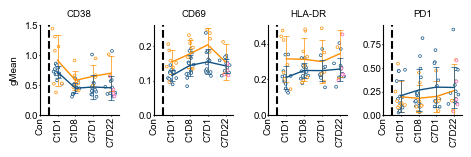

In [36]:
# Make a multiplot of all the graphs for 

# Set font
plt.rcParams["font.family"] = "Arial"
plt.rcParams['svg.fonttype'] = 'none' # export font as editable text
plt.rcParams['pdf.fonttype'] = 'truetype' # export font as editable text

color_dict = {'non-responder_2': '#fe9003', 'responder_1': '#115284', 'Healthy': 'grey'}

cd8_nkt_cytotoxic2 = cd8_nkt_cytotoxic2.loc[cd8_nkt_cytotoxic2['timepoint'] != 'C12D29']


fig, axs = plt.subplots(nrows = 1, ncols = 4, figsize = (6.69 * 0.72, 6.69 * 0.25))
axs_flatten = axs.flatten()

stars = cd8_nkt_cytotoxic2.loc[cd8_nkt_cytotoxic2['timepoint'] == 'SPD', :]['patient_id'].str.replace('_', '').to_list()
figure_list = ['CD38', 'CD69', 'HLA-DR', 'PD1']

jitter_amount = 0.75  # Adjust the jitter amount as needed

x_jitter = np.random.normal(1, jitter_amount, size = cd8_nkt.shape[0])
timejitter =  []
for z, (w, x, y) in enumerate(zip(cd8_nkt_cytotoxic2['time'], cd8_nkt_cytotoxic2['patient_id'], x_jitter)): 
    if (w == 5) & (x in stars): 
        timejitter.append(w + (y/10))
    elif z % 2 == 0:
        timejitter.append(w + (y/10))
    else:
        timejitter.append(w - (y/10))
cd8_nkt_cytotoxic2['time1'] = timejitter

stars1 = cd8_nkt_cytotoxic2.loc[(cd8_nkt_cytotoxic2['patient_id'].isin(stars)) &  (cd8_nkt_cytotoxic2['timepoint'] == 'C7D22'), :]
cd8_nkt_cytotoxic3 = cd8_nkt_cytotoxic2.loc[cd8_nkt['timepoint'] != 'Progression',:]

for y, ax in enumerate(axs_flatten):

        ax.scatter(x = cd8_nkt_cytotoxic3.loc[:,'time1'], y = cd8_nkt_cytotoxic3.loc[:, figure_list[y]], 
              c = 'white', edgecolor = cd8_nkt_cytotoxic3.loc[:,'best_response'].map(color_dict), s =4, lw = 0.5)
        sns.lineplot(data = cd8_nkt_cytotoxic3, x = 'time', y = cd8_nkt_cytotoxic3.loc[:, figure_list[y]], err_style = 'bars',
                 errorbar = 'sd',  err_kws={'linewidth': 0.5, 'capsize':2, 'capthick': 0.5}, legend = False, hue = 'best_response',
                 palette = color_dict, linewidth = 1, ax = ax)
        ax.scatter(x = stars1['time1'], y = stars1[figure_list[y]], color = 'white', s =4, lw = 0.5, edgecolor = 'hotpink')
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.set_ylim(bottom = 0)
        e = str(figure_list[y])
        # e = e.replace('_x', '')
        # e = e.replace('GzmB_pos_CD56_CD8_T_cell', 'GzmB+_CD56+_CD8_T_cell')
        # e = e.replace('GzmB_pos_CD8', 'GzmB+_CD8_T_cell')
        
        e = e.replace('_', ' ')
        
        ax.set_title(e, fontsize = 7)
        ax.axvline(1.5, color = 'black', ls = '--')
        ax.set_xticks([1, 2, 3, 4, 5])
        ax.set_xticklabels(['Con', 'C1D1', 'C1D8', 'C7D1', 'C7D22'], rotation = 90, fontsize = 7)
        ax.set_xlabel(xlabel = '',  fontsize = 7)
        ax.set_ylim(bottom = 0)
        ax.tick_params(axis='both', labelsize=7, pad = 0.1, length = 1)
        if (y % 4 == 0):
            ax.set_ylabel('gMean', fontsize  =7)
        else:
            ax.set_ylabel('', fontsize  =7 )
            
        # Get the axis limits
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()
        
        # Calculate position as a percentage of the axis range
        x_pos = xmin + 0.3 * (xmax - xmin)  # 50% from left
        y_pos = ymax - 0.1 * (ymax - ymin)  # 5% from top

        # text = pval.loc[pval['Cell_type'] == figure_list[y], 'p_value'].iloc[0] 
        # text = round(pval.loc[pval['Cell_type'] == figure_list[y], 'p_value'].iloc[0], 3)
        # text = f'$\it{{p}} = {text}$'
        # ax.text(s = text, x = x_pos, y =  y_pos, fontsize = 7)
    
plt.tight_layout()
#fig.savefig('../results/cd56_pos_acitivation_moleculesfor_main_figure.pdf', dpi = 600)

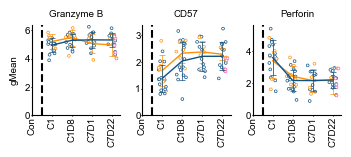

In [38]:

# Make a multiplot of all the graphs for cytotoxic molecules

# Set font
plt.rcParams["font.family"] = "Arial"
plt.rcParams['svg.fonttype'] = 'none' # export font as editable text
plt.rcParams['pdf.fonttype'] = 'truetype' # export font as editable text

color_dict = {'non-responder_2': '#fe9003', 'responder_1': '#115284', 'Healthy': 'grey'}

fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (6.69 * 0.54, 6.69 * 0.25))
axs_flatten = axs.flatten()

cd8_nkt_cytotoxic2 = cd8_nkt_cytotoxic2.loc[cd8_nkt_cytotoxic2['timepoint'] != 'C12D29']
stars = cd8_nkt_cytotoxic2.loc[cd8_nkt_cytotoxic2['timepoint'] == 'SPD', :]['patient_id'].str.replace('_', '').to_list()
figure_list = ['Granzyme_B', 'CD57', 'Perforin']

jitter_amount = 0.75  # Adjust the jitter amount as needed

x_jitter = np.random.normal(1, jitter_amount, size = cd8_nkt.shape[0])
timejitter =  []
for z, (w, x, y) in enumerate(zip(cd8_nkt_cytotoxic2['time'], cd8_nkt_cytotoxic2['patient_id'], x_jitter)): 
    if (w == 5) & (x in stars): 
        timejitter.append(w + (y/10))
    elif z % 2 == 0:
        timejitter.append(w + (y/10))
    else:
        timejitter.append(w - (y/10))
cd8_nkt_cytotoxic2['time1'] = timejitter

stars1 = cd8_nkt_cytotoxic2.loc[(cd8_nkt_cytotoxic2['patient_id'].isin(stars)) &  (cd8_nkt_cytotoxic2['timepoint'] == 'C7D22'), :]
cd8_nkt_cytotoxic3 = cd8_nkt_cytotoxic2.loc[cd8_nkt['timepoint'] != 'Progression',:]

for y, ax in enumerate(axs_flatten):

        ax.scatter(x = cd8_nkt_cytotoxic3.loc[:,'time1'], y = cd8_nkt_cytotoxic3.loc[:, figure_list[y]], 
              c = 'white', edgecolor = cd8_nkt_cytotoxic3.loc[:,'best_response'].map(color_dict), s =4, lw = 0.5)
        sns.lineplot(data = cd8_nkt_cytotoxic3, x = 'time', y = cd8_nkt_cytotoxic3.loc[:, figure_list[y]], err_style = 'bars',
                 errorbar = 'sd',  err_kws={'linewidth': 0.5, 'capsize':2, 'capthick': 0.5}, legend = False, hue = 'best_response',
                 palette = color_dict, linewidth = 1, ax = ax)
        ax.scatter(x = stars1['time1'], y = stars1[figure_list[y]], color = 'white', s =4, edgecolor = 'hotpink', lw = 0.5)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.set_ylim(bottom = 0)
        e = str(figure_list[y])
        
        e = e.replace('_', ' ')
        
        ax.set_title(e, fontsize = 7)
        ax.axvline(1.5, color = 'black', ls = '--')
        ax.set_xticks([1, 2, 3, 4, 5, ])
        ax.set_xticklabels(['Con', 'C1', 'C1D8', 'C7D1', 'C7D22'], rotation = 90, fontsize = 7)
        ax.set_xlabel(xlabel = '',  fontsize = 7)
        ax.set_ylim(bottom = 0)
        ax.tick_params(axis='both', labelsize=7, pad = 0.1, length = 1)
        if (y % 4 == 0):
            ax.set_ylabel('gMean', fontsize  =7)
        else:
            ax.set_ylabel('', fontsize  =7 )
        
        # Get the axis limits
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()
        
        # Calculate position as a percentage of the axis range
        x_pos = xmin + 0.3 * (xmax - xmin)  # 50% from left
        y_pos = ymax - 0.001 * (ymax - ymin)  # 5% from top

        
plt.tight_layout()
#fig.savefig('../results/cd56_pos_cytotoxic_moleculesfor_main_figure.pdf', dpi = 600)

In [ ]:
cell